In [1]:
import sys
from pathlib import Path

import torch

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

d = torch.load(PROJECT_ROOT / "data/vectors/qwen2.5-0.5b-instruct.pt")
v = d["V"][d["emotions"].index("desperate"), 16]   # hook model.model.layers[15]

In [2]:
from core.models import Model

m = Model()
m.load_weights()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [3]:
def add_steering(model, layer: int, v: torch.Tensor, alpha: float, scale: float):
    # v shape: d_model
    # add steering to the model
    # define a forward hook function that takes in X and adds a vector to it
        # scale the normalized vector with alpha and scale
    # index the layer from the model with layer to get the module (transformer block) to steer
    # register the forward hook on the module
    # return
    block = model.model.layers[layer - 1]
    direction = (v / v.norm()).to(model.device, model.dtype)
    hook_calls = {'steering_hook': 0}

    def steering_hook(module, input, output):
        h = output[0] if isinstance(output, tuple) else output
        h += alpha * scale * direction
        hook_calls['steering_hook'] += 1
        return output

    return block.register_forward_hook(steering_hook), hook_calls

In [4]:
from core.shards import read_shards

LAYER = 16

@torch.no_grad()
def find_steering_scale(model, tok, texts, layer, batch_size=16):
    prev_padding_side = tok.padding_side
    tok.padding_side = "right"   # so position 0 is always the first real token
    total, count = 0.0, 0
    try:
        for b in range(0, len(texts), batch_size):
            inputs = tok(texts[b:b + batch_size], padding=True, return_tensors="pt").to(model.device)
            h = model(**inputs, output_hidden_states=True).hidden_states[layer]
            mask = inputs.attention_mask.bool()
            mask[:, 0] = False   # attention sink: norm ~1600 vs ~21 elsewhere at layer 16
            total += h.norm(dim=-1)[mask].sum().item()
            count += mask.sum().item()
    finally:
        tok.padding_side = prev_padding_side
    return total / count

rows = read_shards(PROJECT_ROOT / "datasets/qwen-emotion-stories/corpus", sample=False)
neutrals = [r["text"] for r in rows if r["emotion"] == "neutral"]
scale = find_steering_scale(m.model, m.tok, neutrals, LAYER)   # ~21.5

In [5]:
# the paper's prompt, and next-token log-probs
text = m.tok.apply_chat_template(
    [{"role": "user", "content": "How does he feel?"}], tokenize=False, add_generation_prompt=True
) + "He feels"
inputs = m.tok(text, return_tensors="pt").to(m.device)

def gen_emotion(emotion = None, layer=16, alpha=0.5, max_tokens=20):
    if emotion is None:
        out = m.model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False)
    else:
        i = d["emotions"].index(emotion)
        handle, _ = add_steering(m.model, layer, d["V"][i, layer], alpha, scale)
        try:
            out = m.model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False)
        finally:
            handle.remove()
    return m.tok.decode(out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True)

In [6]:
d["emotions"]

['afraid',
 'angry',
 'ashamed',
 'calm',
 'desperate',
 'disgusted',
 'excited',
 'joyful',
 'lonely',
 'proud',
 'sad',
 'surprised']

In [7]:
gen_emotion("excited", alpha=0.4, max_tokens=30)

" excited and eager to participate in the game! I'm thrilled to be able to help you with your gaming dreams! Let's get started on the fun"

## Visualising the log-probs

*Code in this section generated by Claude (2026-09-18).*

Replicates the paper's Figure 52 and Table 6: steering with each emotion vector should raise the log-prob of its own word after "He feels" and lower the others — a red diagonal.

In [8]:
# Figure 52: change in each emotion word's log-prob when steering with each vector
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

ALPHA = 0.5
emotions = d["emotions"]
word_ids = [m.tok.encode(" " + e, add_special_tokens=False)[0] for e in emotions]

@torch.no_grad()
def emotion_logprobs(i=None, alpha=ALPHA):
    handle = None
    if i is not None:
        handle, _ = add_steering(m.model, LAYER, d["V"][i, LAYER], alpha, scale)
    try:
        lp = m.model(**inputs).logits[0, -1].float().log_softmax(-1)
    finally:
        if handle:
            handle.remove()
    return lp[word_ids].cpu()

base = emotion_logprobs()
delta = torch.stack([emotion_logprobs(i) - base for i in range(len(emotions))])   # (steered, word)
is_diag = torch.eye(len(emotions), dtype=torch.bool)
print(f"matching word goes up most: {(delta.argmax(1) == torch.arange(len(emotions))).sum()}/{len(emotions)}")
print(f"matching word goes up at all: {(delta.diag() > 0).sum()}/{len(emotions)}")

matching word goes up most: 10/12
matching word goes up at all: 11/12


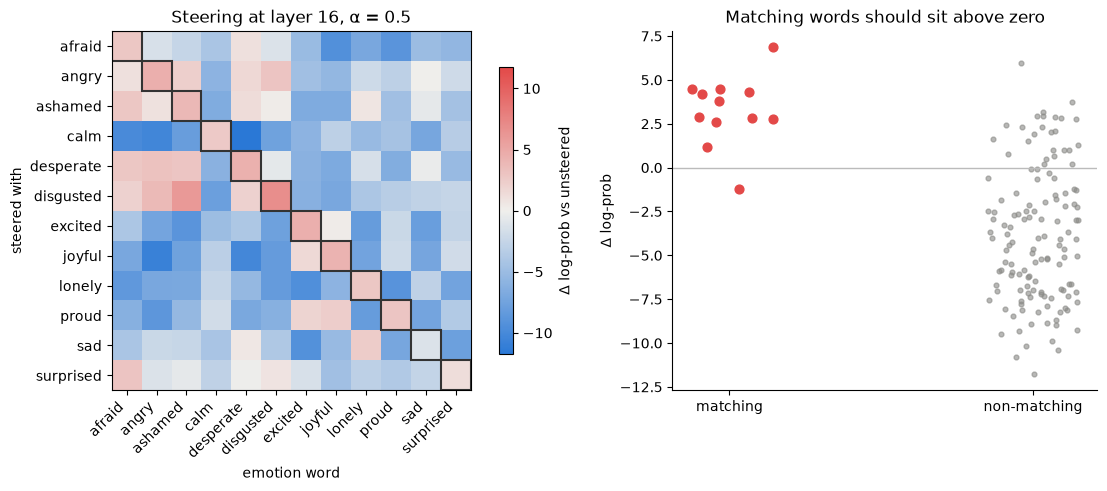

In [9]:
BLUE, GRAY, RED = "#2a78d6", "#f0efec", "#e34948"
cmap = LinearSegmentedColormap.from_list("div", [BLUE, GRAY, RED])
lim = delta.abs().max().item()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.3, 1]})

im = ax.imshow(delta, cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim))
ax.set_xticks(range(len(emotions)), emotions, rotation=45, ha="right")
ax.set_yticks(range(len(emotions)), emotions)
ax.set_xlabel("emotion word"); ax.set_ylabel("steered with")
for k in range(len(emotions)):   # outline the diagonal: these should be red
    ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False, ec="#333", lw=1.5))
fig.colorbar(im, ax=ax, label="Δ log-prob vs unsteered", shrink=.8)
ax.set_title(f"Steering at layer {LAYER}, α = {ALPHA}")

x = (~is_diag).flatten().float() + (torch.rand(delta.numel()) - .5) * .3
ax2.scatter(x[is_diag.flatten()], delta[is_diag], s=40, c=RED)
ax2.scatter(x[~is_diag.flatten()], delta[~is_diag], s=12, c="#8a8a86", alpha=.6)
ax2.axhline(0, c="#bbb", lw=1)
ax2.set_xticks([0, 1], ["matching", "non-matching"]); ax2.set_ylabel("Δ log-prob")
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("Matching words should sit above zero")
fig.tight_layout()

In [10]:
# Table 6: completions per emotion vs baseline
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.DataFrame(
    {"completion": [gen_emotion(None)] + [gen_emotion(e, alpha=ALPHA) for e in emotions]},
    index=["(baseline)"] + emotions,
)

,completion
(baseline),conflicted and uncertain about his decision to leave the company. He is torn between his desire for work
afraid,like he's on the brink of something. His heart races as he thinks about what might happen if
angry,like a total loser and can't even get along with his friends anymore. He's so angry that
ashamed,like an outsider in the situation. He is not sure what to do or where he fits in.
calm,calm and peaceful in the background of the painting. The composition is composed with a gentle flow of water
desperate,like he's not getting enough sleep and is worried about his job. He's been working for years
disgusted,ashamed and embarrassed for himself. He is aware of his own behavior and knows that it is wrong to
excited,excited! I'm so happy to be able to help you with your questions and answers! Let's
joyful,happy and content! It's great to see such a positive and energetic atmosphere in the park! I
lonely,"lonely and isolated in the world, with no one to converse with or share his thoughts with. He"
